# Phase 1 - Parse Log với Drain3

In [11]:
pip install -q drain3

Note: you may need to restart the kernel to use updated packages.


In [12]:
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig
from pathlib import Path
from datetime import datetime
import re
import pandas as pd

In [13]:
best_sim_th = 0.5
config = TemplateMinerConfig()
config.drain_sim_th = best_sim_th
miner = TemplateMiner(config=config)
log_file = "D:\\AI\\AWS\\Phase2\\W1\\day-2\\HDFS_v1\\HDFS.log"
results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)

ts_pattern = re.compile(r"^(?P<date>\d{6})\s+(?P<time>\d{6})")
blk_pattern = re.compile(r"(blk_-?\d+)")

records = []
total_lines = 0

# Doc va parse log (stream tung dong de giam RAM)
with open(log_file, 'r', encoding='utf-8', errors='ignore') as f:
    for i, line in enumerate(f, start=1):
        total_lines = i
        result = miner.add_log_message(line.strip())
        m = ts_pattern.match(line)
        ts = None
        if m:
            ts = datetime.strptime(m.group("date") + m.group("time"), "%y%m%d%H%M%S")
        blk_match = blk_pattern.search(line)
        records.append({
            "timestamp": ts,
            "template_id": result["cluster_id"],
            "block_id": blk_match.group(1) if blk_match else None
        })
        if i % 1000000 == 0:
            print(f"Da parse {i} dong")

print(f"Tong so dong: {total_lines}")
df_logs = pd.DataFrame(records)

clusters = miner.drain.clusters
template_counts = sorted(clusters, key=lambda c: c.size, reverse=True)
print(f"So template unique: {len(template_counts)}")

top_templates_data = []
for cluster in template_counts[:10]:
    top_templates_data.append({
        'template_id': cluster.cluster_id,
        'template': cluster.get_template(),
        'count': cluster.size
    })

df_top = pd.DataFrame(top_templates_data)
output_path = results_dir / "top_templates.csv"
df_top.to_csv(output_path, index=False)
print(f"Da xuat top 10 templates ra {output_path}")
print(df_top)

analysis_miner = miner

Da parse 1000000 dong
Da parse 2000000 dong
Da parse 3000000 dong
Da parse 4000000 dong
Da parse 5000000 dong
Da parse 6000000 dong
Da parse 7000000 dong
Da parse 8000000 dong
Da parse 9000000 dong
Da parse 10000000 dong
Da parse 11000000 dong
Tong so dong: 11175629
So template unique: 55
Da xuat top 10 templates ra results\top_templates.csv
   template_id                                           template    count
0            1  <*> <*> <*> INFO dfs.DataNode$DataXceiver: Rec...  1723232
1            5  <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* Name...  1719741
2            4  <*> <*> <*> INFO dfs.DataNode$PacketResponder:...  1706514
3           17  <*> <*> <*> INFO dfs.FSDataset: Deleting block...  1402047
4           31  <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* Name...  1396174
5           49  081111 <*> <*> INFO dfs.DataNode$PacketRespond...   859939
6           36  081110 <*> <*> INFO dfs.DataNode$PacketRespond...   680085
7           34  <*> <*> <*> WARN dfs.DataNode$DataXceive

In [14]:
sim_values = [0.3, 0.5, 0.7]
sample_size = 200000
tuning_results = []

for sim_th in sim_values:
    cfg = TemplateMinerConfig()
    cfg.drain_sim_th = sim_th
    tmp_miner = TemplateMiner(config=cfg)
    with open(log_file, 'r', encoding='utf-8', errors='ignore') as f:
        for i, line in enumerate(f, start=1):
            tmp_miner.add_log_message(line.strip())
            if i >= sample_size:
                break
    num_templates = len(tmp_miner.drain.clusters)
    tuning_results.append({"drain_sim_th": sim_th, "num_templates": num_templates})

df_tuning = pd.DataFrame(tuning_results)
df_tuning.to_csv(results_dir / "drain_sim_th_tuning.csv", index=False)
print(f"Tuning tren {sample_size} dong mau")
print(df_tuning)

Tuning tren 200000 dong mau
   drain_sim_th  num_templates
0           0.3             30
1           0.5             25
2           0.7          36340


# Phase 2 - Anomaly Detection trên Log

So anomalous points: 366
Top templates bi spike:
template_id
47    30
3     19
2     19
9     17
8     17
10    16
34    15
16    13
38    12
18    12
Name: count, dtype: int64
New templates xuat hien trong 1h gan nhat: []


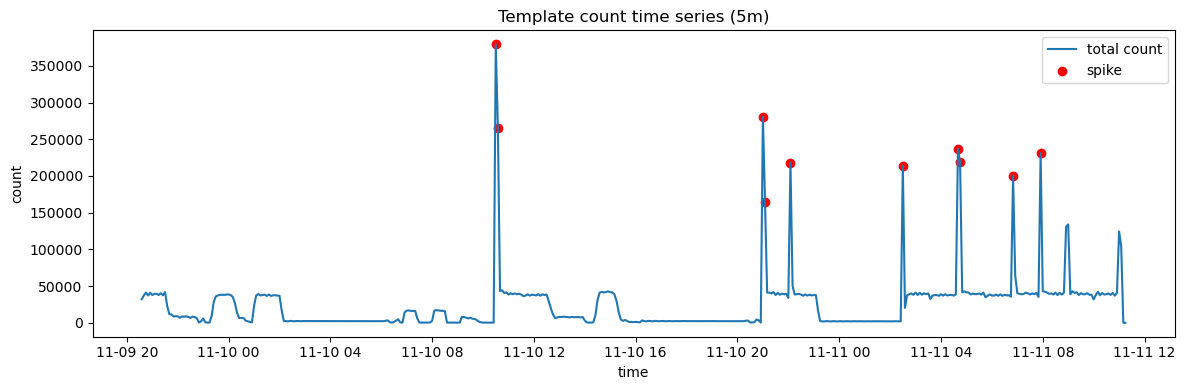

In [15]:
import matplotlib.pyplot as plt

df_logs_valid = df_logs.dropna(subset=["timestamp"]).copy()
if df_logs_valid.empty:
    print("Khong co timestamp hop le de tao time series")
    anomalies = pd.DataFrame(columns=["timestamp", "template_id", "is_anomaly"])
else:
    ts_counts = df_logs_valid.groupby([
        pd.Grouper(key="timestamp", freq="5min"),
        "template_id"
    ]).size().unstack(fill_value=0)

    mu = ts_counts.mean()
    sigma = ts_counts.std().replace(0, pd.NA)
    threshold = mu + 3 * sigma
    anomaly_mask = ts_counts.gt(threshold)
    anomalies = anomaly_mask.stack()
    anomalies = anomalies[anomalies].reset_index()
    anomalies.columns = ["timestamp", "template_id", "is_anomaly"]

    print("So anomalous points:", len(anomalies))
    print("Top templates bi spike:")
    print(anomalies["template_id"].value_counts().head(10))

    last_ts = ts_counts.index.max()
    last_hour_start = last_ts - pd.Timedelta(hours=1)
    first_seen = df_logs_valid.groupby("template_id")["timestamp"].min()
    new_templates = first_seen[first_seen >= last_hour_start].index.tolist()
    print("New templates xuat hien trong 1h gan nhat:", new_templates)

    total_counts = ts_counts.sum(axis=1)
    total_mu = total_counts.mean()
    total_sigma = total_counts.std()
    total_threshold = total_mu + 3 * total_sigma
    spike_points = total_counts[total_counts > total_threshold]

    plt.figure(figsize=(12, 4))
    plt.plot(total_counts.index, total_counts.values, label="total count")
    plt.scatter(spike_points.index, spike_points.values, color="red", label="spike")
    plt.title("Template count time series (5m)")
    plt.xlabel("time")
    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()

In [19]:
labels_path = Path("HDFS_v1/preprocessed/anomaly_label.csv")
if labels_path.exists():
    labels = pd.read_csv(labels_path)
    labels.columns = [c.strip().lower() for c in labels.columns]
    if "blockid" in labels.columns:
        labels = labels.rename(columns={"blockid": "block_id"})
    if "label" not in labels.columns and "anomaly" in labels.columns:
        labels = labels.rename(columns={"anomaly": "label"})

    df_logs["window"] = df_logs["timestamp"].dt.floor("5min")
    anomaly_pairs = anomalies[["timestamp", "template_id"]].drop_duplicates()
    anomaly_pairs = anomaly_pairs.rename(columns={"timestamp": "window"})
    df_logs = df_logs.merge(
        anomaly_pairs.assign(is_anomaly=True),
        on=["window", "template_id"],
        how="left"
    )
    df_logs["is_anomaly"] = df_logs["is_anomaly"].fillna(False).astype(bool)

    pred = df_logs.groupby("block_id")["is_anomaly"].any().reset_index()
    pred = pred.rename(columns={"is_anomaly": "pred"})
    merged = labels.merge(pred, on="block_id", how="left").fillna({"pred": False})

    y_true = merged["label"].astype(str).str.lower().isin(["anomaly", "1", "true", "yes"])
    y_pred = merged["pred"].astype(bool)
    tp = int((y_true & y_pred).sum())
    fp = int((~y_true & y_pred).sum())
    fn = int((y_true & ~y_pred).sum())
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    print(f"precision={precision:.4f}, recall={recall:.4f}")
else:
    print("Khong tim thay anomaly_label.csv trong HDFS_v1/preprocessed")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_26344\3702409799.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_logs["is_anomaly"] = df_logs["is_anomaly"].fillna(False).astype(bool)


precision=0.0259, recall=0.7037


# Phase 3 - Embedding + Cross-signal

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

template_list = [c.get_template() for c in analysis_miner.drain.clusters]
template_ids = [c.cluster_id for c in analysis_miner.drain.clusters]
print("So template cho TF-IDF:", len(template_list))

vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b")
tfidf = vectorizer.fit_transform(template_list)
sim_matrix = cosine_similarity(tfidf)

top_similar = []
for i, tid in enumerate(template_ids):
    sims = sim_matrix[i]
    top_idx = sims.argsort()[-4:-1][::-1]
    for j in top_idx:
        top_similar.append({
            "template_id": tid,
            "similar_template_id": template_ids[j],
            "score": float(sims[j])
        })

df_sim = pd.DataFrame(top_similar).sort_values("score", ascending=False)
df_sim.to_csv(results_dir / "template_similarity_top.csv", index=False)
print(df_sim.head(10))

new_log = "000000 000000 000 INFO dfs.DataNode$PacketResponder: New unusual error code XYZ"
before_count = len(analysis_miner.drain.clusters)
new_result = analysis_miner.add_log_message(new_log)
after_count = len(analysis_miner.drain.clusters)
print("New template created:", after_count > before_count)
print("New template id:", new_result["cluster_id"])
print("New template:", new_result["template_mined"])

So template cho TF-IDF: 55
     template_id  similar_template_id     score
30            11                    9  1.000000
21             8                   12  1.000000
24             9                    9  1.000000
33            12                   12  1.000000
66            23                   27  0.906081
78            27                   23  0.906081
63            22                   39  0.887743
114           39                   22  0.887743
117           40                   51  0.874312
150           51                   40  0.874312
New template created: True
New template id: 56
New template: 000000 000000 000 INFO dfs.DataNode$PacketResponder: New unusual error code XYZ
